# HW04 - Classification

The aims of this exercise are to 1) get started with classification, to 2) be able to evaluate the classification results with the given task in mind, and to 3) be able to create visualizations that are useful in the evaluation.

Please note that you should read the chapter 3 “Classification” of the course book “Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow” 2023/3rd editions by Aurélien Géron or the class materials to complete the tasks of this exercise successfully.

Embed all your theory answers, drawings, source codes and screen shots directly into this document. Always immediately after the relevant question. 

Return the document into your return box in ItsLearning environment by the deadline. Please remember to mark the number of points that you should get from this exercise according to your own evaluation. The maximum number of points available in this exercise is **15**. You can check the task specific points directly from each task. 

In addition to the course book, it’s also recommendable to use other books and Internet sources to find supplementary information.

**Please note:** This homework covers two weeks of lectures (**Binary Classification** and **Multiclass Classification**).
- **Part 1 (Questions 1–3):** Complete before our next lecture on **March 3rd**.
- **Part 2 (Questions 4–7):** Complete by the final deadline on **March 9th, 2026**.

## Part 1: Binary Classification and Performance Measures

1)	Train a binary classifier SGD according to the instructions in the course book with one important exception: Select one digit, but not the digit 5. (**1 point**)

In [3]:
from sklearn.datasets import fetch_openml
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import cross_val_score
import numpy as np

# Loading MNIST

mnist = fetch_openml('mnist_784', as_frame = False)
X, y = mnist["data"], mnist["target"]

# Converting the labels to integers

y = y.astype(np.uint8)

# Spliting the  train/test

X_train, X_test = X[:60000], X[60000:]
y_train, y_test = y[:60000], y[60000:]

y_train_binary = (y_train == 3)
y_test_binary = (y_test == 3)

# Traiing the SGD classifier

sgd_clf = SGDClassifier(random_state = 42)
sgd_clf.fit(X_train, y_train_binary)

SGDClassifier(random_state=42)

2)	Use 5-fold cross-validation. Continue with the digit you selected in task 1. What are the minimum and maximum accuracies you get? What is the accuracy, and is it a good measure to evaluate the model in this case? (**2 point**)

In [4]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score

scores = cross_val_score(sgd_clf, X_train, y_train_binary, cv = 5, scoring = "accuracy")

print("Scores:", scores)
print("Min accuracy:", scores.min())
print("Max accuracy:", scores.max())
print("Mean accuracy:", scores.mean())

# Doing predictions using the cross-validation

y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_binary, cv = 5)

Scores: [0.92858333 0.94975    0.96316667 0.96108333 0.96691667]
Min accuracy: 0.9285833333333333
Max accuracy: 0.9669166666666666
Mean accuracy: 0.9539


3)	Calculate the confusion matrix, and then, precision, recall and F1 measures. Continue with the digit you selected in task 1. (4 * 1 = **4 points**)

In [5]:
# Using a confusion matrix to check

cm = confusion_matrix(y_train_binary, y_train_pred)
print("Confusion Matrix:\n", cm)

# Metrics of the scores

precision = precision_score(y_train_binary, y_train_pred)
recall = recall_score(y_train_binary, y_train_pred)
f1 = f1_score(y_train_binary, y_train_pred)

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Confusion Matrix:
 [[52096  1773]
 [  993  5138]]
Precision: 0.7434524670814643
Recall: 0.8380362094274996
F1 Score: 0.7879159638092317


## Part 2: Multiclass Classification and Performance Measures

4)	Precision/Recall trade-off. Continue with the digit you selected in task 1.

a)	Draw a diagram like the figure 3-5 in the course book. (**1 point**)

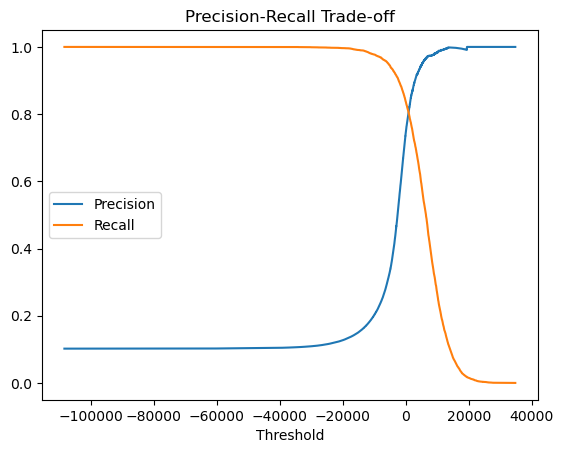

In [6]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

y_scores = cross_val_predict(
    sgd_clf,
    X_train,
    y_train_binary,
    cv = 5,
    method = "decision_function"
)

precisions, recalls, thresholds = precision_recall_curve(y_train_binary, y_scores)

plt.plot(thresholds, precisions[:-1], label = "Precision")
plt.plot(thresholds, recalls[:-1], label = "Recall")
plt.xlabel("Threshold")
plt.legend()
plt.title("Precision-Recall Trade-off")
plt.show()

b)	Draw a diagram like the figure 3-6 in the course book. (**1 point**)

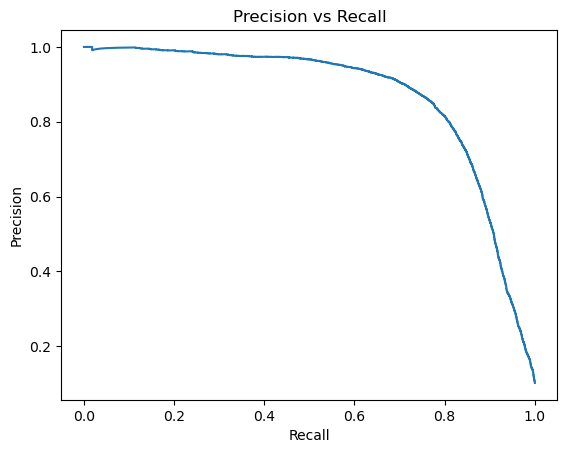

In [7]:
plt.plot(recalls, precisions)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision vs Recall")
plt.show()

5)	Carefully study the ROC Curve from either the extra materials provided in Itslearning under the Plans in week 10 or your course book. Then draw the ROC-curve and explain AUC. (2 * 1 = **2 point**)

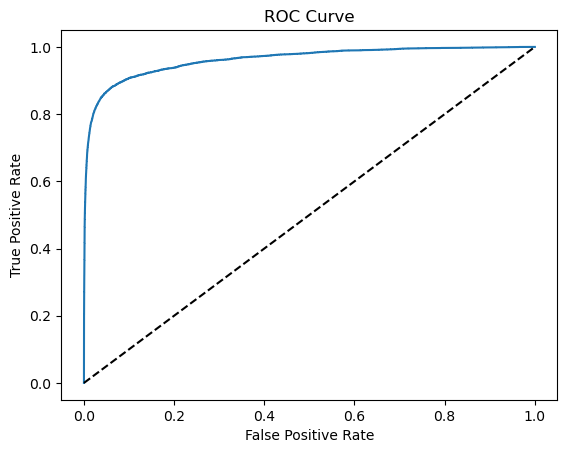

AUC: 0.9624114801125387


In [8]:
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

fpr, tpr, thresholds = roc_curve(y_train_binary, y_scores)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

auc = roc_auc_score(y_train_binary, y_scores)
print("AUC:", auc)

AUC could be explain in simple terms as the area under the curve, some simple integral is enough when we have the curve equation and the limits of it (0 and 1 of course). That would show us how well the classifier would separate two classes for example or a bit more in this specific situation the ability to rank positive examples higher than the negative ones.

6)	Multiclass classification. (2 * 1 = **2 points**)

a)	Explain OvR and OvO.

a) OvR vs OvO

One-vs-Rest or else OvR. Trains one classifier per class. For example, 0 vs others or 1 vs others or 2 vs others.

One-vs-One or else OvO. It trains a classifier for every pair of classes we need. For example, for 10 digits we would get 45 classifiers.

b)	Select and perform one of them.

In [9]:
sgd_clf.fit(X_train, y_train)

y_pred = sgd_clf.predict(X_test)

7)	If you were developing a machine learning model to find fraudulent credit card transactions, which measure would you give more importance: Precision or Recall? Carefully justify your decision. (**2 points**)

In the scenario of fraud detection, for example, a missing a fraudulent transaction is much worse than wrongly flagging a normal one. A high recall would ensure that most fraudulent transactions are detected, even if it means investigating some false positives. So I believe recall is more important.